# Exploratory Data Analysis (EDA) - Credit Card Dataset
## Phân tích phân phối, tương quan và đặc trưng của dữ liệu

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from IPython.display import display

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

## 1. Load và khám phá dữ liệu

In [2]:
# Load dataset
DATA_PATH = Path('../data/raw/creditcard.csv')

if not DATA_PATH.exists():
    raise FileNotFoundError(f'Khong tim thay file: {DATA_PATH.resolve()}')

df = pd.read_csv(DATA_PATH)

print(f'Dataset da tai thanh cong!')
print(f'Kich thuoc: {df.shape[0]:,} dong x {df.shape[1]} cot')
print(f'\nCac cot:')
print(df.columns.tolist())

Dataset da tai thanh cong!
Kich thuoc: 284,807 dong x 31 cot

Cac cot:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


In [3]:
# Hien thi mau du lieu
print("\nMot vai dong dau tien:")
display(df.head())


Mot vai dong dau tien:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 2. Thông tin cơ bản

In [4]:
print("="*70)
print("THONG TIN CO BAN VE DATASET")
print("="*70)

print(f"\nHinh dang: {df.shape}")
print(f"\nKieu du lieu:")
display(df.dtypes.value_counts().to_frame())

print(f"\nGia tri thieu:")
missing = df.isnull().sum()
if missing.sum() > 0:
    display(missing[missing > 0].to_frame())
else:
    print("Khong co gia tri thieu")

print(f"\nGia tri trung lap: {df.duplicated().sum()}")

THONG TIN CO BAN VE DATASET

Hinh dang: (284807, 31)

Kieu du lieu:


,count
float64,30
int64,1



Gia tri thieu:
Khong co gia tri thieu

Gia tri trung lap: 1081


In [5]:
# Thông tin chi tiết
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

## 3. Thống kê mô tả

In [6]:
print("\nThong ke mo ta cho cac cot so:")
display(df.describe().T)


Thong ke mo ta cho cac cot so:


,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,1.175161e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.384974e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.094852e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,1.021879e-15,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,1.494498e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-5.620335e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.0,1.149614e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.0,-2.414189e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995


In [7]:
# Lấy các cột số
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"\nSố cột số: {len(numeric_cols)}")
print(f"Các cột số: {numeric_cols}")


Số cột số: 31
Các cột số: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


## 4. Phân tích phân phối

PHÂN TÍCH PHÂN PHỐI


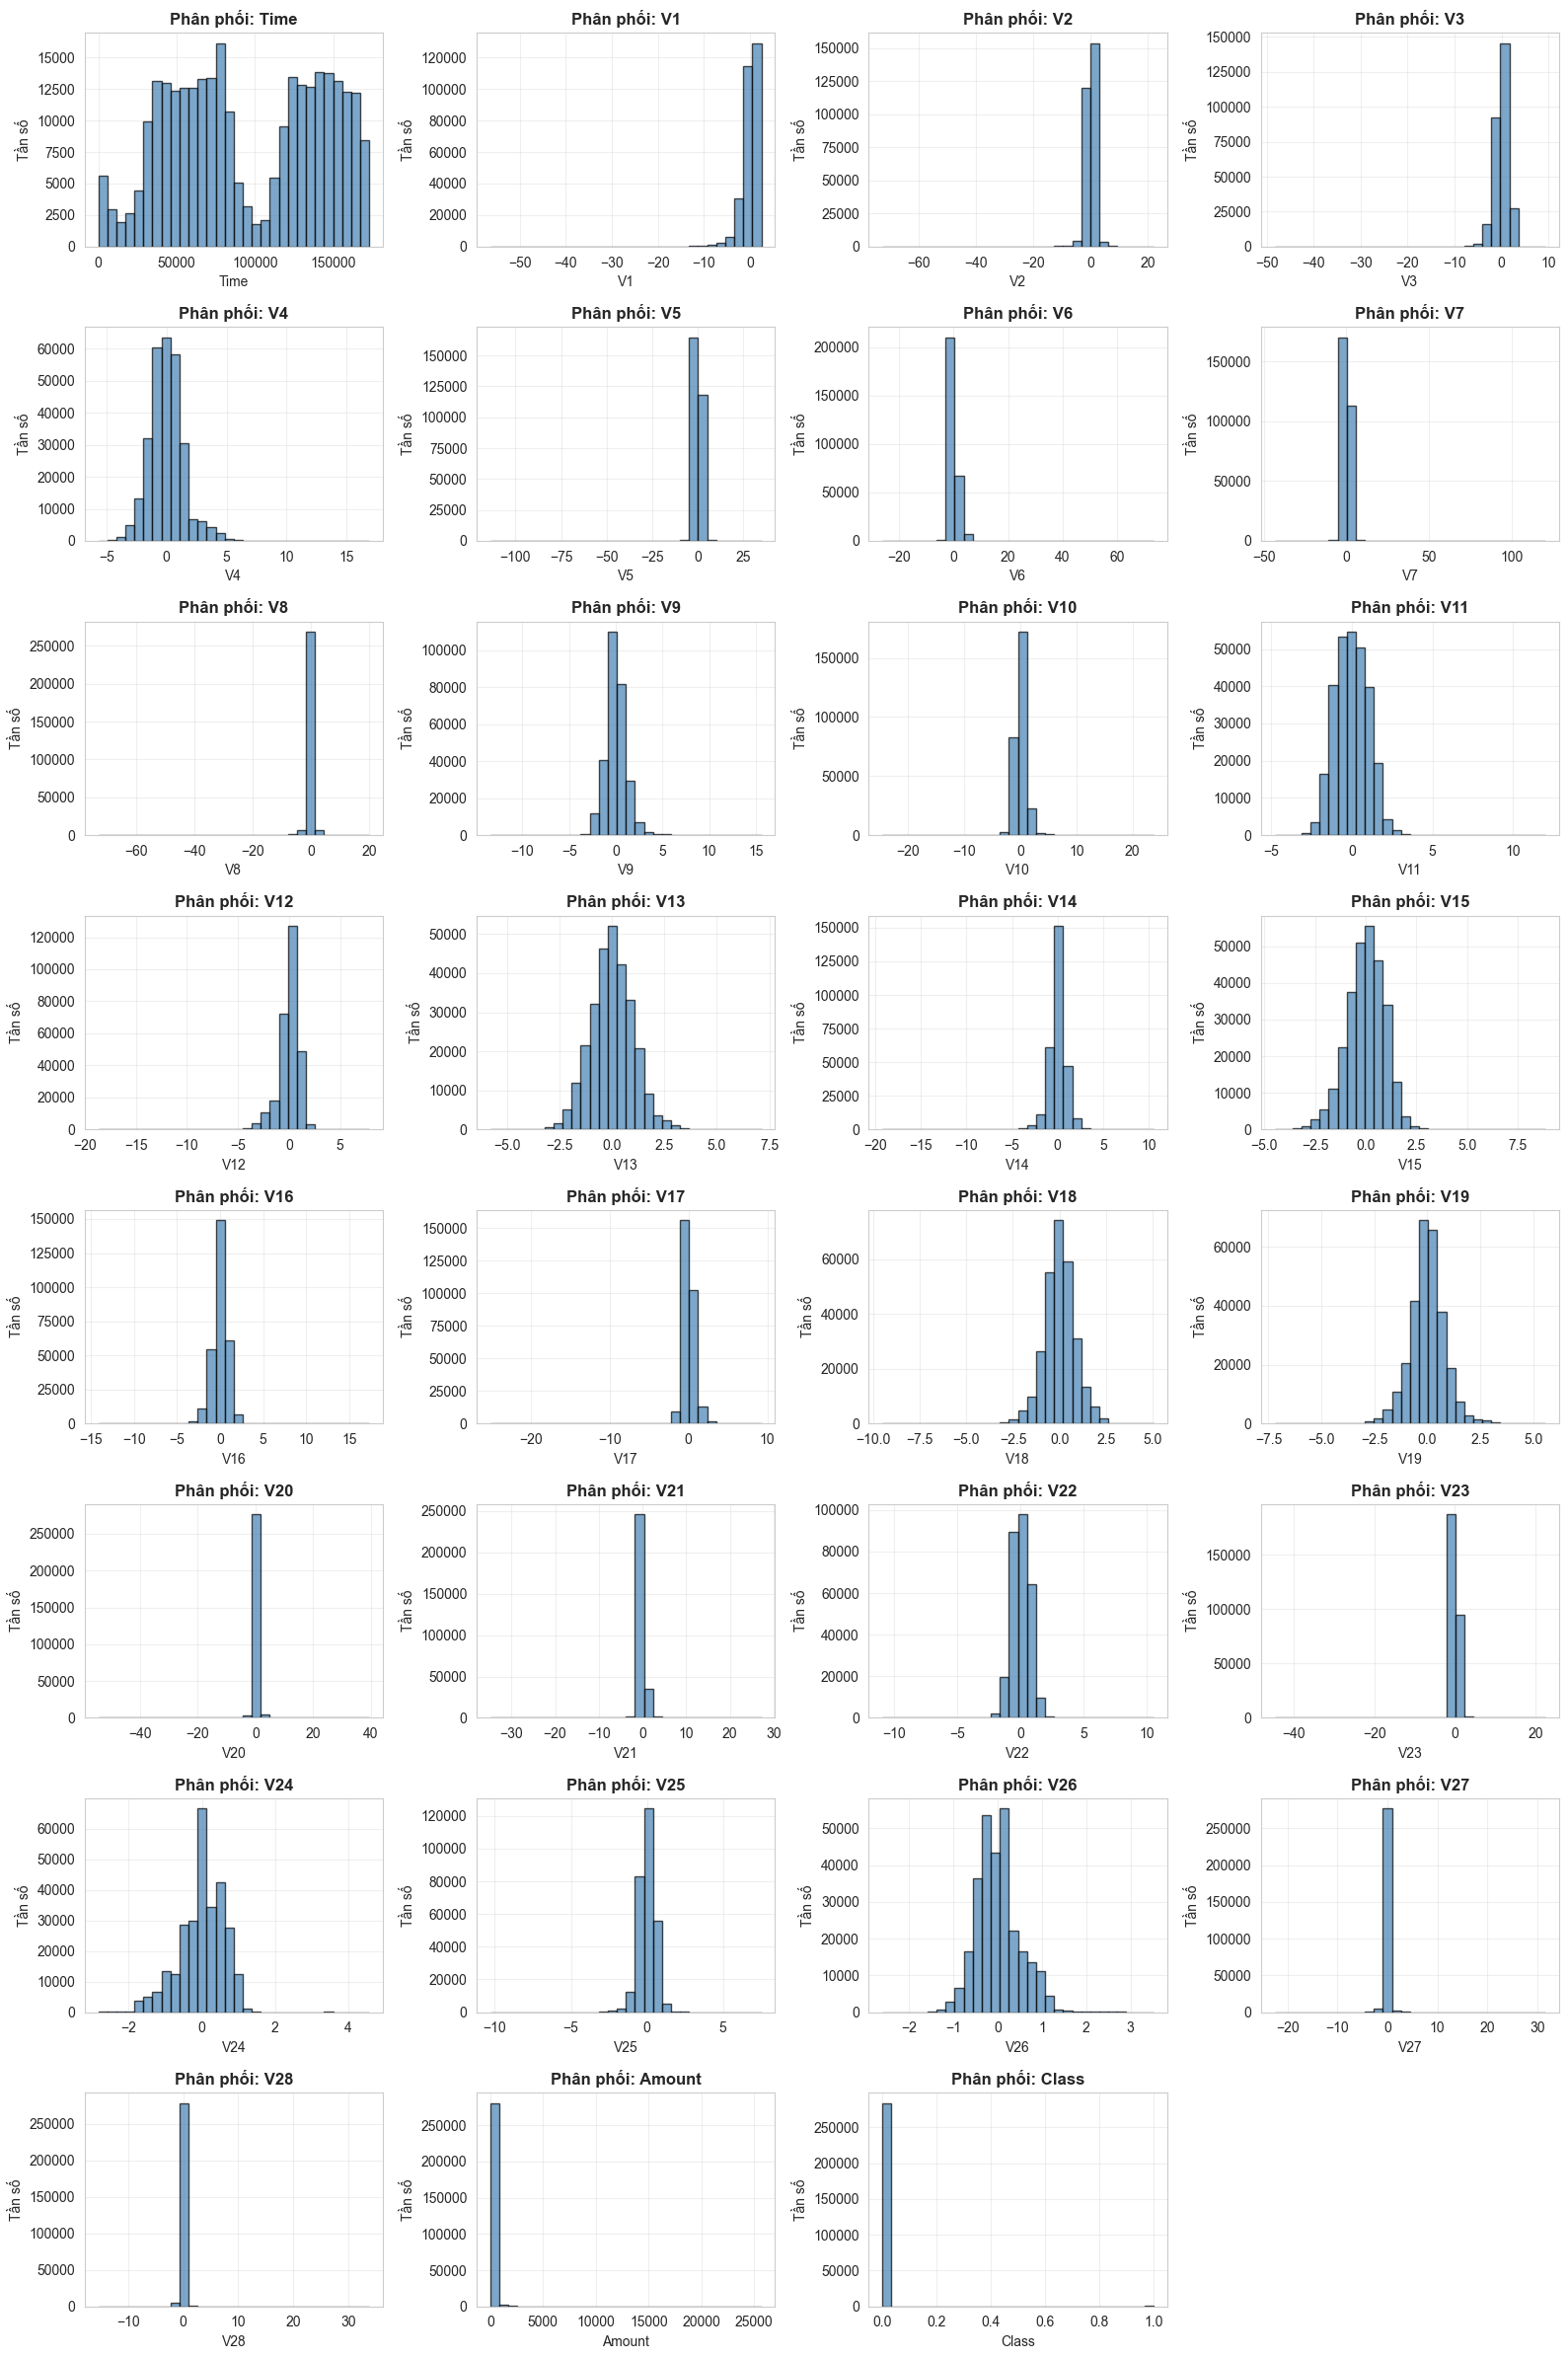

Histogram da duoc luu!


In [8]:
print("="*70)
print("PHÂN TÍCH PHÂN PHỐI")
print("="*70)

# Histogram cho các cột số
n_cols = len(numeric_cols)
n_rows = (n_cols + 3) // 4

fig, axes = plt.subplots(n_rows, 4, figsize=(16, n_rows*3))
axes = axes.flatten()

for idx, col in enumerate(numeric_cols):
    axes[idx].hist(df[col], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'Phân phối: {col}', fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Tần số')
    axes[idx].grid(alpha=0.3)

# Ẩn subplot thừa
for idx in range(len(numeric_cols), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig('../data/processed/01_distributions_histograms.png', dpi=300, bbox_inches='tight')
plt.show()

print("Histogram da duoc luu!")

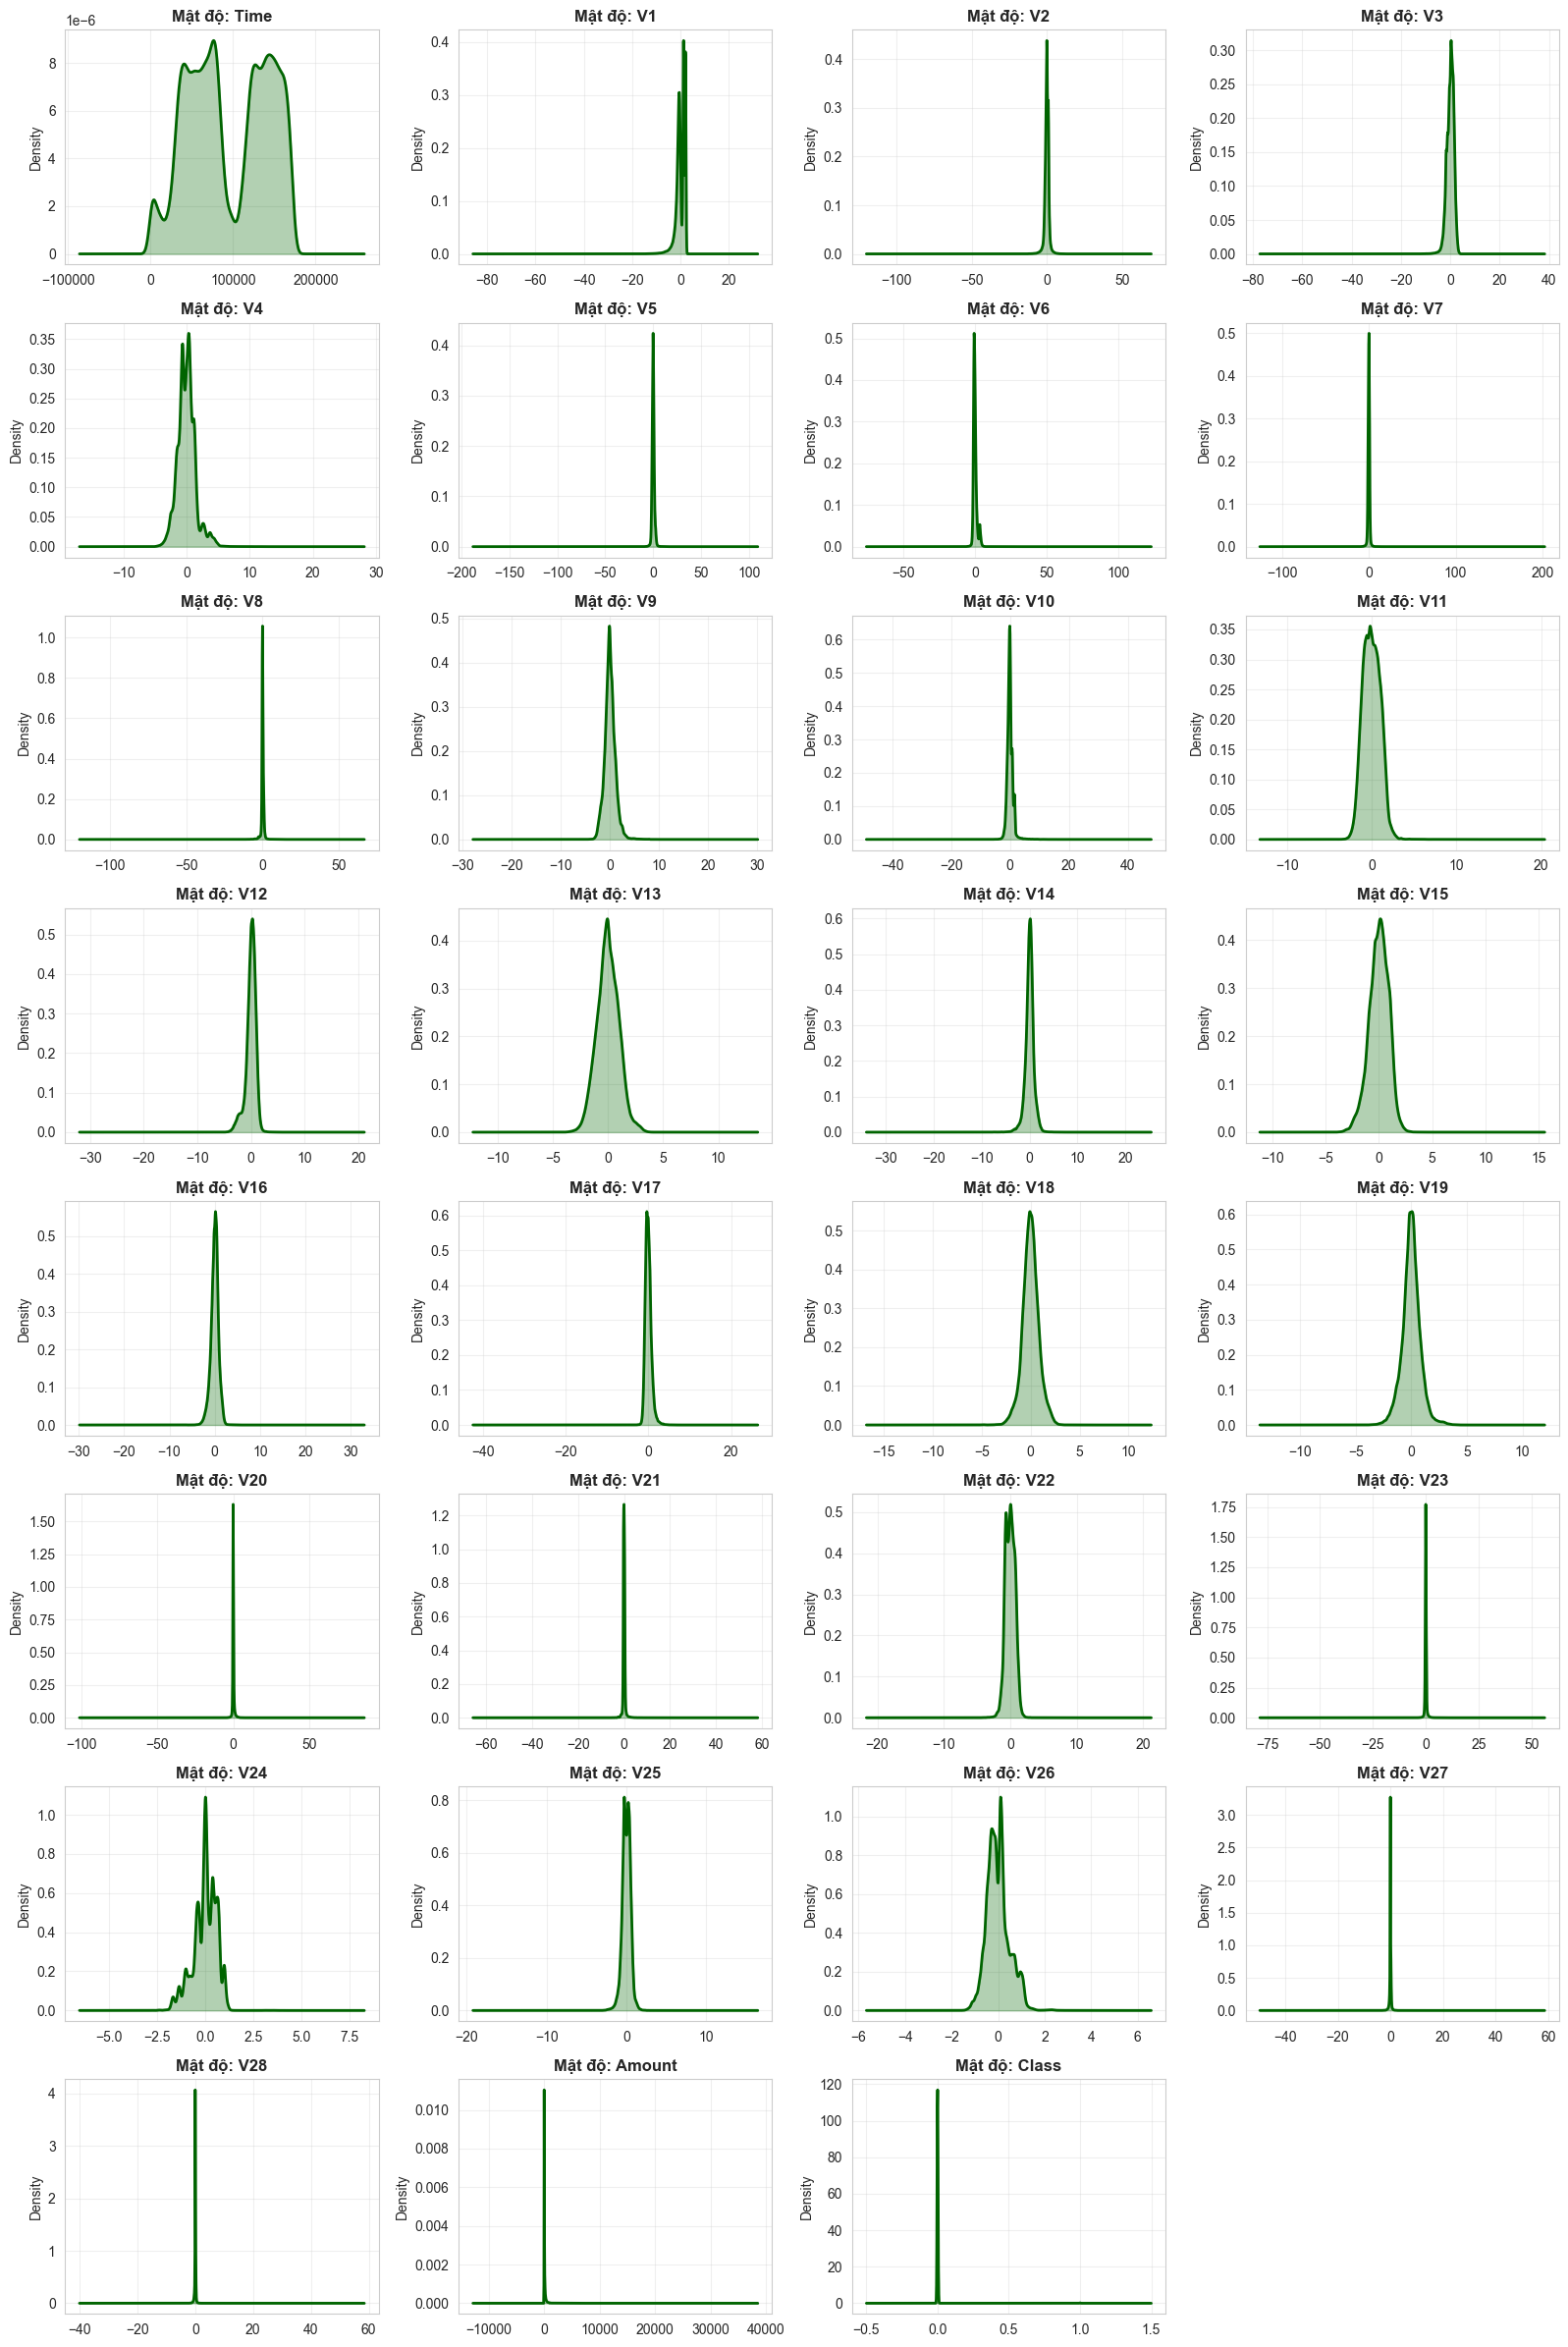

Density plot da duoc luu!


In [9]:
# Density plots
fig, axes = plt.subplots(n_rows, 4, figsize=(16, n_rows*3))
axes = axes.flatten()

for idx, col in enumerate(numeric_cols):
    df[col].plot(kind='density', ax=axes[idx], color='darkgreen', linewidth=2)
    axes[idx].set_title(f'Mật độ: {col}', fontweight='bold')
    axes[idx].grid(alpha=0.3)
    axes[idx].fill_between(axes[idx].lines[0].get_xdata(), 
                            axes[idx].lines[0].get_ydata(), 
                            alpha=0.3, color='darkgreen')

for idx in range(len(numeric_cols), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig('../data/processed/02_distributions_density.png', dpi=300, bbox_inches='tight')
plt.show()

print("Density plot da duoc luu!")

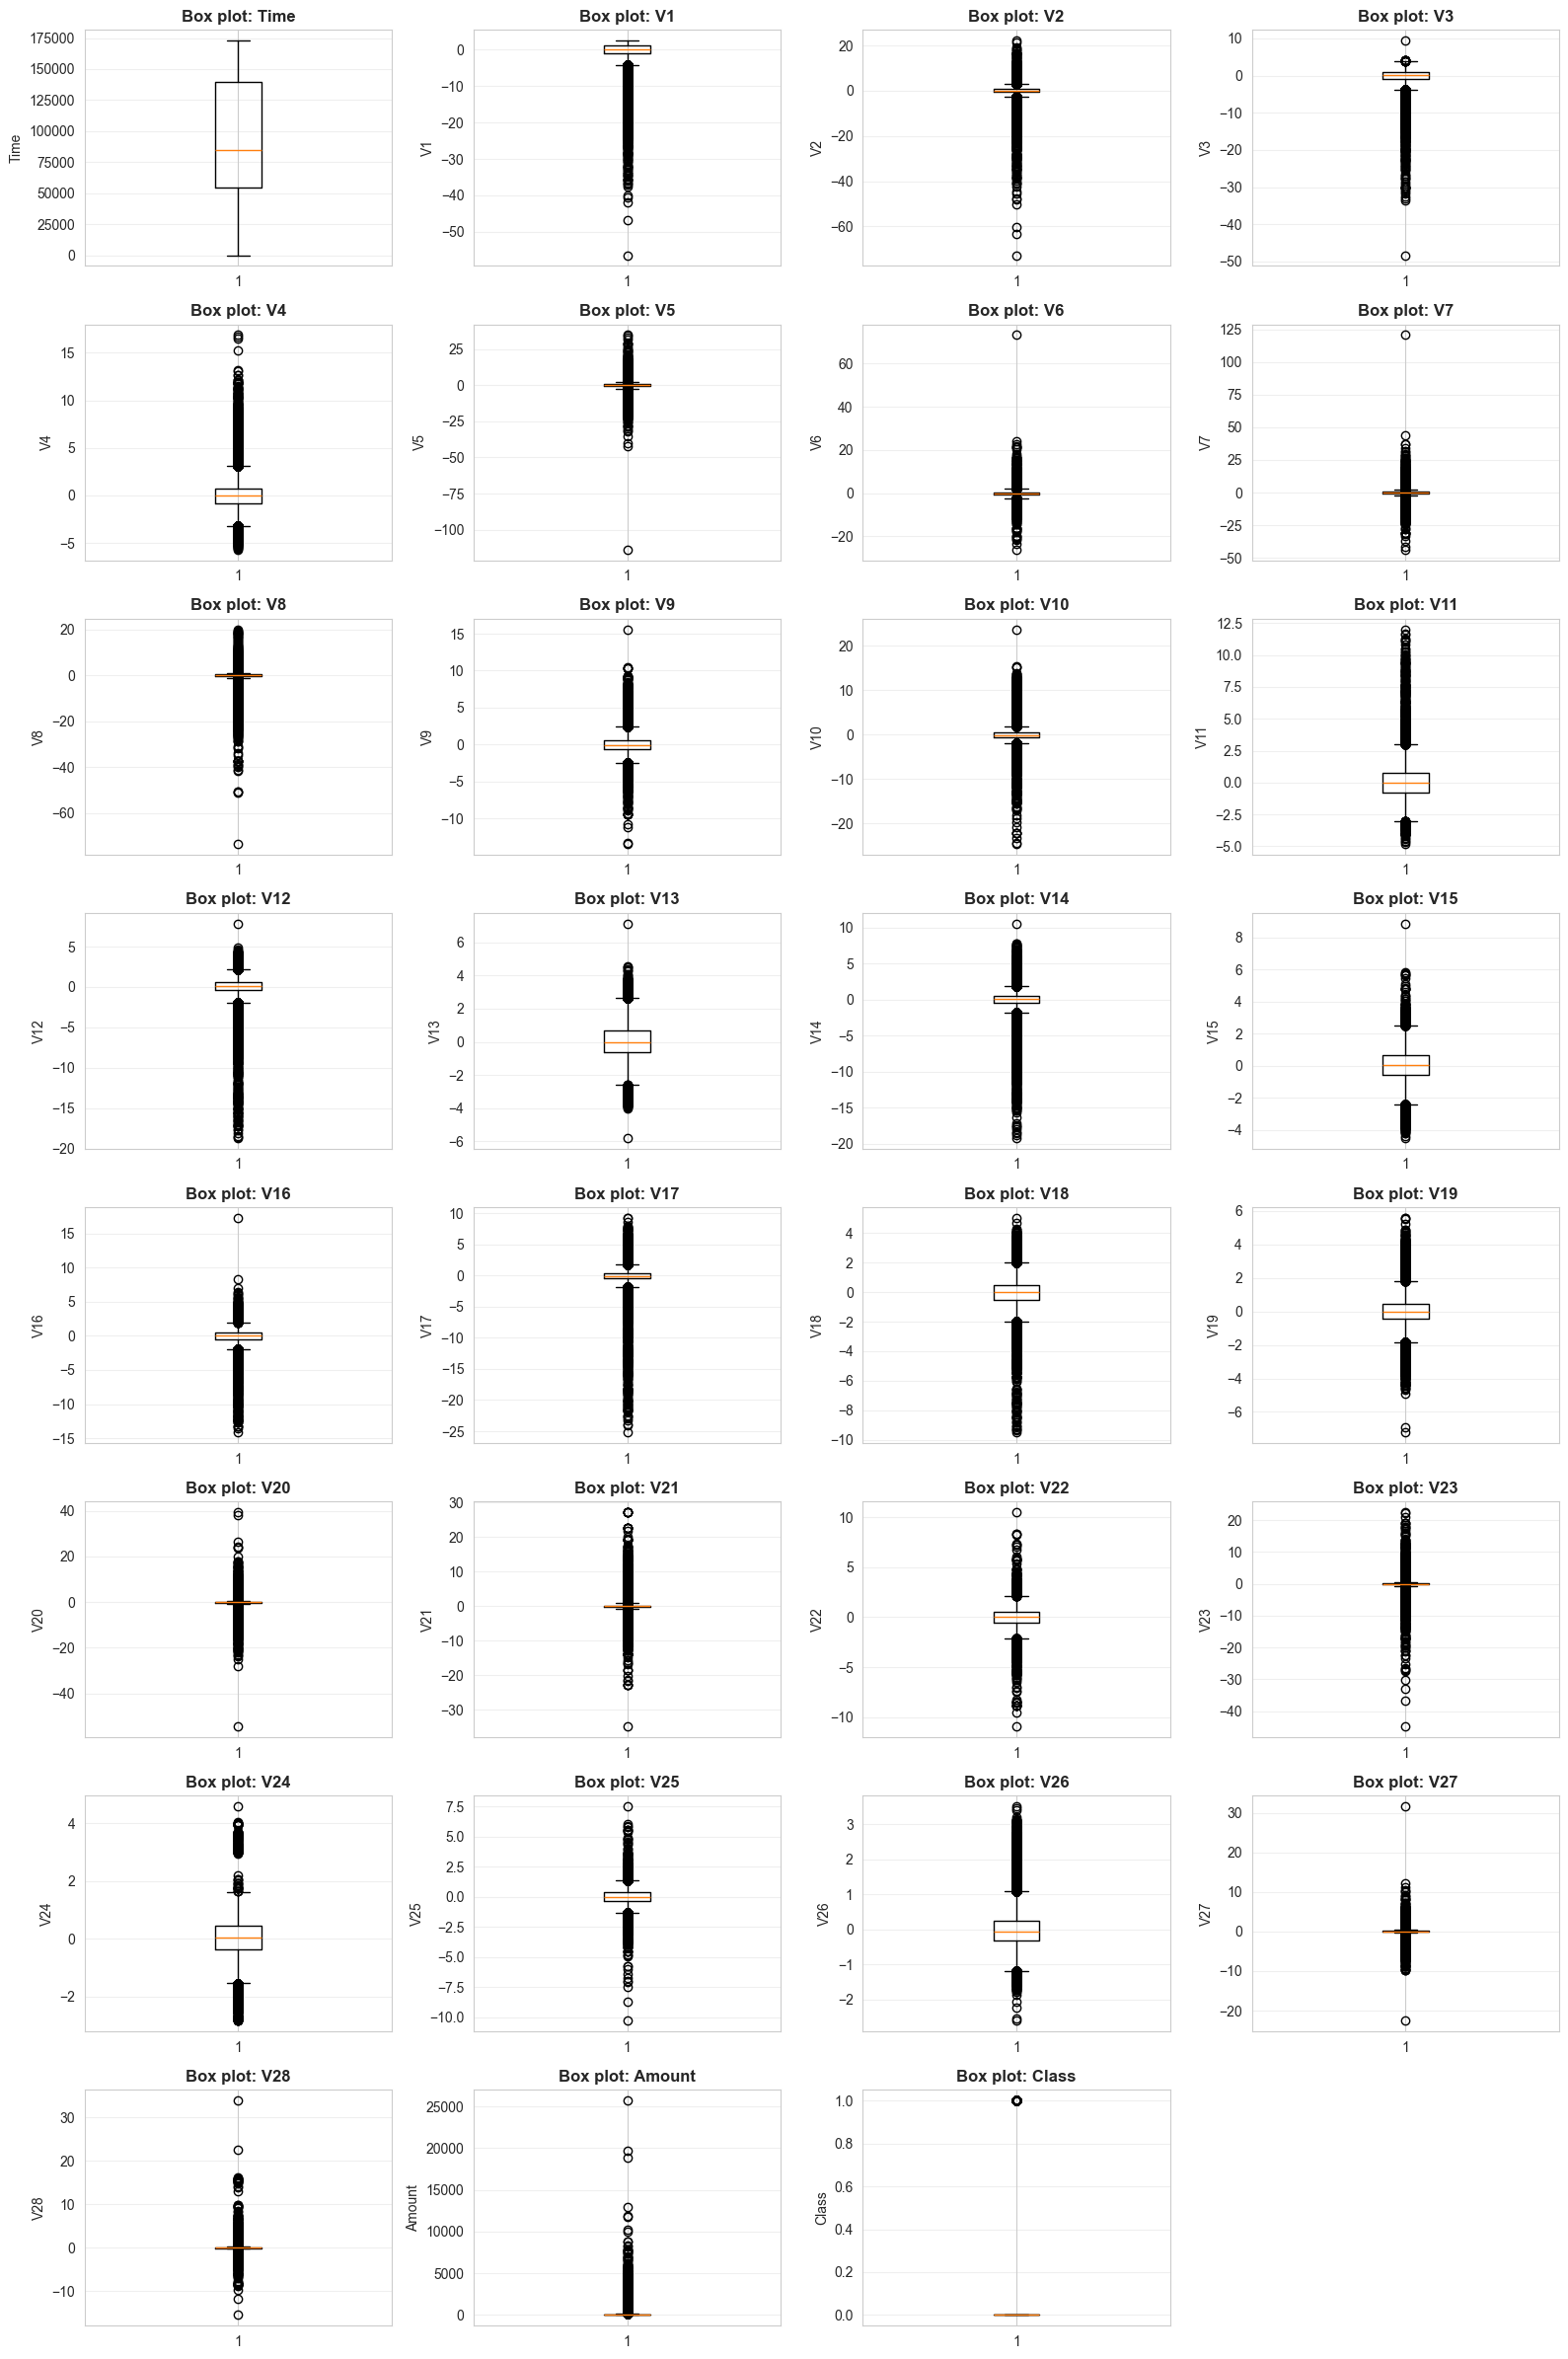

Box plot da duoc luu!


In [10]:
# Box plots để phát hiện outliers
fig, axes = plt.subplots(n_rows, 4, figsize=(16, n_rows*3))
axes = axes.flatten()

for idx, col in enumerate(numeric_cols):
    axes[idx].boxplot(df[col], vert=True)
    axes[idx].set_title(f'Box plot: {col}', fontweight='bold')
    axes[idx].set_ylabel(col)
    axes[idx].grid(alpha=0.3, axis='y')

for idx in range(len(numeric_cols), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig('../data/processed/03_distributions_boxplots.png', dpi=300, bbox_inches='tight')
plt.show()

print("Box plot da duoc luu!")

## 5. Phân tích tương quan

In [11]:
print("="*70)
print("PHÂN TÍCH TƯƠNG QUAN")
print("="*70)

# Tính ma trận tương quan
corr_matrix = df[numeric_cols].corr()

print(f"\nHình dạng ma trận tương quan: {corr_matrix.shape}")
print(f"\nTop 10 tương quan cao nhất (tuyệt đối):")

# Lấy các cặp tương quan cao nhất (không phải đường chéo)
def get_top_correlations(corr_matrix, n=10):
    pairs = []
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            pairs.append({
                'Feature 1': corr_matrix.columns[i],
                'Feature 2': corr_matrix.columns[j],
                'Correlation': corr_matrix.iloc[i, j]
            })
    pairs_df = pd.DataFrame(pairs)
    return pairs_df.iloc[pairs_df['Correlation'].abs().argsort(descending=True)[:n]]

# Lấy top correlations theo cách khác
pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        pairs.append({
            'Feature 1': corr_matrix.columns[i],
            'Feature 2': corr_matrix.columns[j],
            'Correlation': corr_matrix.iloc[i, j]
        })
pairs_df = pd.DataFrame(pairs)
top_corr = pairs_df.nlargest(10, 'Correlation', keep='all')
print("\nTop 10 tuong quan cao nhat (tuyet doi):")
display(top_corr)

PHÂN TÍCH TƯƠNG QUAN

Hình dạng ma trận tương quan: (31, 31)

Top 10 tương quan cao nhất (tuyệt đối):

Top 10 tuong quan cao nhat (tuyet doi):


,Feature 1,Feature 2,Correlation
210,V7,Amount,0.397311
418,V20,Amount,0.339403
187,V6,Amount,0.215981
4,Time,V5,0.173072
293,V11,Class,0.154876
21,Time,V22,0.144059
139,V4,Class,0.133447
11,Time,V12,0.124348
0,Time,V1,0.117396
427,V21,Amount,0.105999


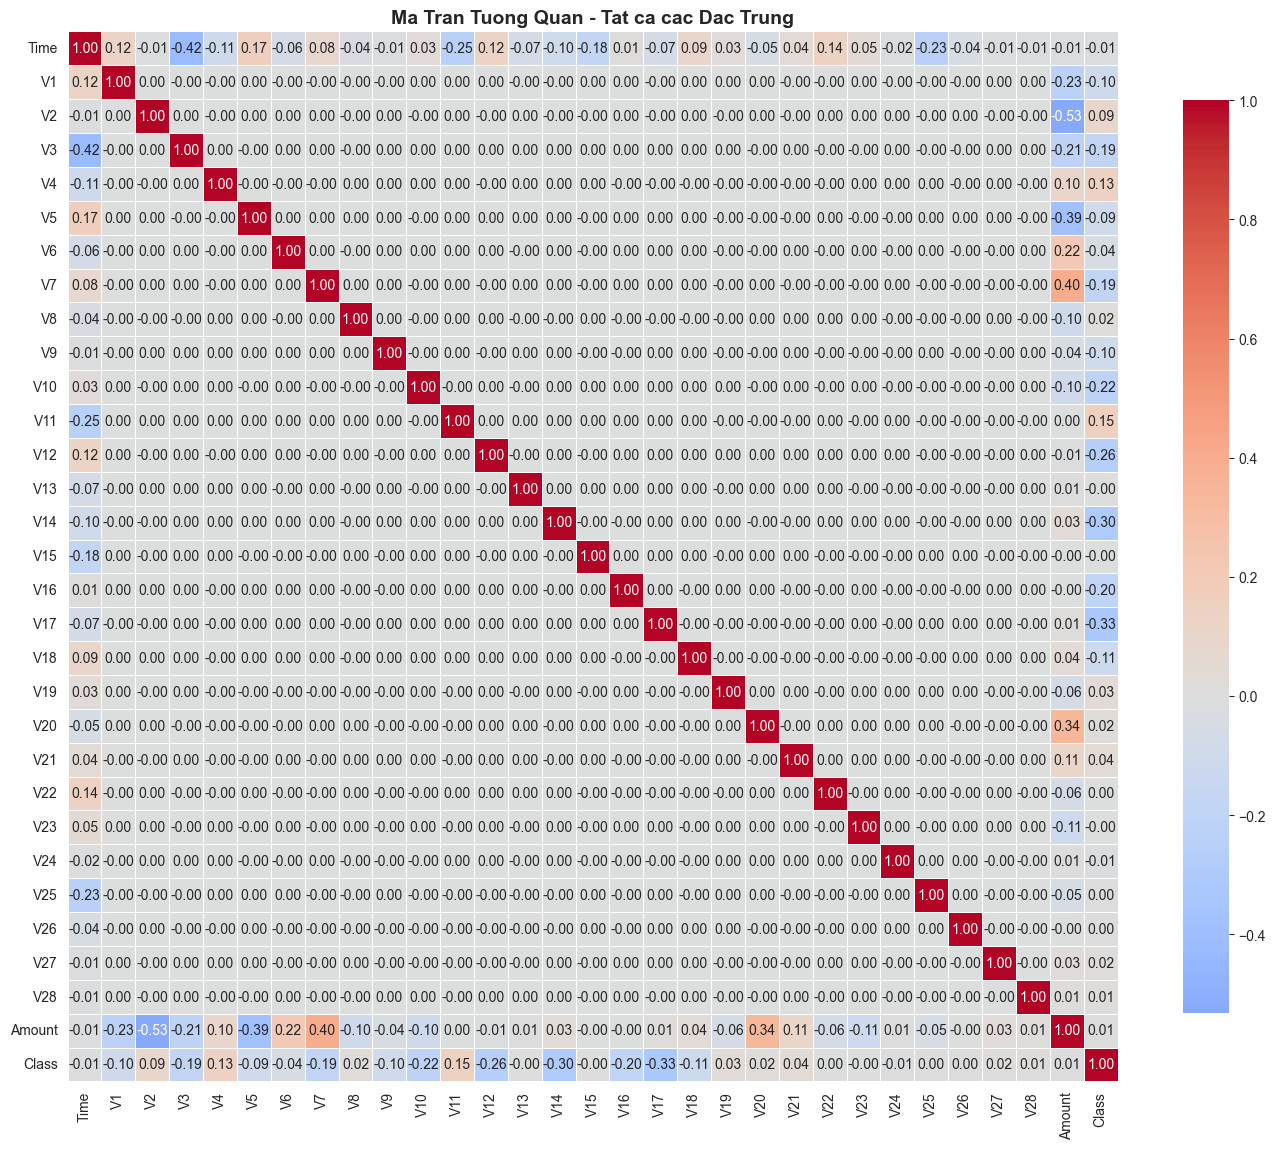

Ma tran tuong quan da duoc luu!


In [12]:
# Ma trận tương quan heatmap
plt.figure(figsize=(14, 12))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Ma Tran Tuong Quan - Tat ca cac Dac Trung', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig('../data/processed/04_correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("Ma tran tuong quan da duoc luu!")

## 6. Phân tích các đặc trưng chính

PHÂN TÍCH CHI TIẾT MỘT SỐ ĐẶC TRƯNG

Phan bo Class:


,count
Class,
0,284315
1,492



Ti le:


,proportion
Class,
0,0.998273
1,0.001727


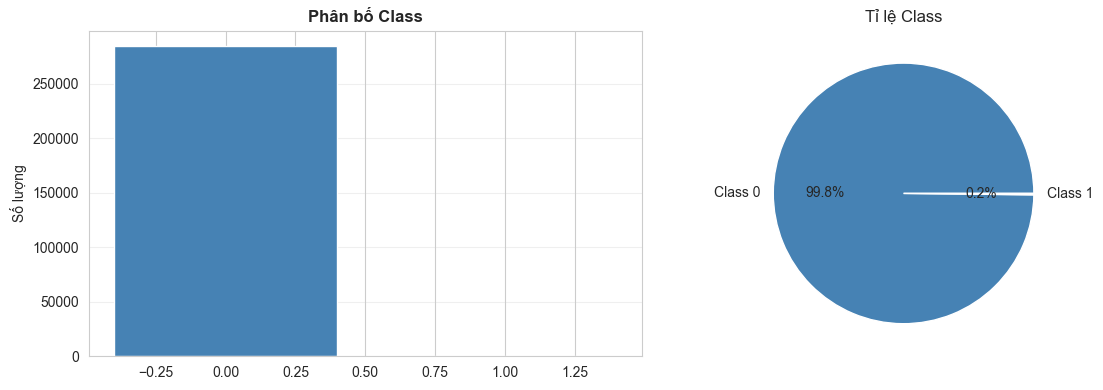

Class distribution plot da duoc luu!


In [13]:
print("="*70)
print("PHÂN TÍCH CHI TIẾT MỘT SỐ ĐẶC TRƯNG")
print("="*70)

# Nếu có cột 'Class' (fraud detection)
if 'Class' in df.columns:
    print(f"\nPhan bo Class:")
    display(df['Class'].value_counts().to_frame())
    print(f"\nTi le:")
    display(df['Class'].value_counts(normalize=True).to_frame())
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    class_counts = df['Class'].value_counts()
    axes[0].bar(class_counts.index, class_counts.values, color=['steelblue', 'coral'])
    axes[0].set_title('Phân bố Class', fontweight='bold')
    axes[0].set_ylabel('Số lượng')
    axes[0].grid(alpha=0.3, axis='y')
    
    axes[1].pie(class_counts.values, labels=[f'Class {i}' for i in class_counts.index],
                autopct='%1.1f%%', colors=['steelblue', 'coral'])
    axes[1].set_title('Tỉ lệ Class')
    
    plt.tight_layout()
    plt.savefig('../data/processed/05_class_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("Class distribution plot da duoc luu!")

In [14]:
# Phân tích các cột object/categorical
object_cols = df.select_dtypes(include='object').columns.tolist()

if object_cols:
    print(f"\nCac cot categorical: {object_cols}")
    
    for col in object_cols[:5]:
        print(f"\n{col} - So gia tri unique: {df[col].nunique()}")
        print(f"Top 5 gia tri:")
        display(df[col].value_counts().head())

## 7. Tóm tắt EDA

In [16]:
print("="*70)
print("TOM TAT PHAN TICH KHAAM PHA DU LIEU (EDA)")
print("="*70)

print(f"\nTHONG TIN CHUNG:")
print(f"  Tong so mau: {len(df):,}")
print(f"  Tong so dac trung: {len(df.columns)}")
print(f"  Cot so: {len(numeric_cols)}")
print(f"  Cot categorical: {len(object_cols)}")

print(f"\nDU LIEU:")
print(f"  Gia tri thieu: {df.isnull().sum().sum()}")
print(f"  Gia tri trung lap: {df.duplicated().sum()}")
print(f"  Dung luong: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")



TOM TAT PHAN TICH KHAAM PHA DU LIEU (EDA)

THONG TIN CHUNG:
  Tong so mau: 284,807
  Tong so dac trung: 31
  Cot so: 31
  Cot categorical: 0

DU LIEU:
  Gia tri thieu: 0
  Gia tri trung lap: 1081
  Dung luong: 67.36 MB
